<a href="https://colab.research.google.com/github/ag999git/001-Python-book-2026/blob/main/colab-nb/12-pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 12: Pandas, an open source data analysis and manipulation tool

This notebook holds the code examples of Chapter 12. You do not need to type them. Run them, read the notes, and then change the code to see what happens.

Pandas is the library that turns Python into a data analysis tool. It gives you two structures, the **Series** (one column) and the **DataFrame** (a whole table), and hundreds of methods for loading, cleaning, summarising and reshaping data.

### How this notebook is arranged

- Each code example from the book is in its own code cell.
- Before every example there is a text cell. It tells you what the code does, how it does it, why it matters, and what you should learn from it.
- Some examples also have a text cell after them. Its heading starts with "Notes on Example" and the example number, so you always know which code cell it talks about.
- A few short cells are marked **Try it**. They are not in the book. They let you see something the book describes in words.
- At the end of every section there is a link that takes you back to the Table of Contents.
- A short "Beyond the Book" section at the end adds a few extras. You can skip it on the first reading.

### How to run the code

1. Click inside a code cell.
2. Press **Shift + Enter**, or click the round Run button on the left of the cell.
3. The result appears just below the cell.

Run the cells from top to bottom. Pandas, NumPy, Seaborn and Matplotlib are already installed in Colab.

**Some cells need the internet.** They read files from public web addresses, or load a Seaborn dataset. Colab has an internet connection, so they work there. If a cell fails with a connection error, the website may be busy or the file may have moved. Run the cell again later, or use another of the examples.

**Warnings in pink boxes.** A few cells print a `FutureWarning`. That is Pandas telling you that a way of writing something will change in a later version. The code still runs correctly. The notes explain each one.

### How to read the flowcharts

The steps are numbered 1, 2, 3 and so on. When the flow splits into two paths, one path uses the letter A (2A, 3A ...) and the other uses the letter B (2B, 3B ...). A long chain of steps is folded onto a second row: follow the arrow down and back to the left.

## <a name="toc"></a>Table of Contents

- [Learning objectives](#learning-objectives)
- [12.1 Introduction to datasets in Pandas](#12-1-introduction-to-datasets-in-pandas)
- [12.2 Types of data in a dataset](#12-2-types-of-data-in-a-dataset)
    - [12.2.1 The penguins dataset](#12-2-1-the-penguins-dataset)
    - [Example 1: Loading the penguins dataset](#example-1-loading-the-penguins-dataset)
    - [12.2.2 The flights dataset](#12-2-2-the-flights-dataset)
    - [Example 2: Loading the flights dataset](#example-2-loading-the-flights-dataset)
    - [12.2.3 The tips dataset](#12-2-3-the-tips-dataset)
    - [Example 3: Loading the tips dataset](#example-3-loading-the-tips-dataset)
- [12.3 Introduction to Pandas](#12-3-introduction-to-pandas)
    - [12.3.1 The relationship between NumPy and Pandas](#12-3-1-the-relationship-between-numpy-and-pandas)
    - [12.3.2 Installing and importing Pandas](#12-3-2-installing-and-importing-pandas)
    - [12.3.3 The "vectorized" nature of Pandas](#12-3-3-the-vectorized-nature-of-pandas)
    - [12.3.4 Example 4: Vectorization in Pandas](#12-3-4-example-4-vectorization-in-pandas)
- [12.4 Basics of Pandas](#12-4-basics-of-pandas)
- [12.5 The Series data structure](#12-5-the-series-data-structure)
    - [12.5.1 Two fundamental ways to create a Series](#12-5-1-two-fundamental-ways-to-create-a-series)
    - [Example 5: Seven ways to create a Series](#example-5-seven-ways-to-create-a-series)
    - [Notes on Example 5](#notes-on-example-5)
- [12.6 The DataFrame](#12-6-the-dataframe)
    - [12.6.1 How DataFrames are created](#12-6-1-how-dataframes-are-created)
    - [Example 6: Three manual ways to build a DataFrame](#example-6-three-manual-ways-to-build-a-dataframe)
    - [Example 7: Reading a CSV, an Excel file and a JSON string](#example-7-reading-a-csv-an-excel-file-and-a-json-string)
    - [Example 8: From a NumPy array, and from Series](#example-8-from-a-numpy-array-and-from-series)
- [12.7 The index of a DataFrame](#12-7-the-index-of-a-dataframe)
    - [12.7.1 Default index compared with custom index](#12-7-1-default-index-compared-with-custom-index)
    - [Example 9: Default index and set_index()](#example-9-default-index-and-set-index)
    - [12.7.2 Unique and non-unique indexes](#12-7-2-unique-and-non-unique-indexes)
    - [Try it: a non-unique index in action](#try-it-a-non-unique-index-in-action)
- [12.8 Important DataFrame attributes](#12-8-important-dataframe-attributes)
    - [Example 10: The five fundamental attributes](#example-10-the-five-fundamental-attributes)
    - [Notes on Example 10](#notes-on-example-10)
- [12.9 DataFrame operations: the four pillars](#12-9-dataframe-operations-the-four-pillars)
    - [Try it: one small example from each pillar](#try-it-one-small-example-from-each-pillar)
- [12.10 Research topics and projects](#12-10-research-topics-and-projects)
- [12.11 Pivot tables](#12-11-pivot-tables)
    - [What to notice about this sales data](#what-to-notice-about-this-sales-data)
    - [What to notice about the pivot table](#what-to-notice-about-the-pivot-table)
    - [The pivot_table() signature](#the-pivot-table-signature)
    - [Example 11: pivot_table(), stack() and unstack()](#example-11-pivot-table-stack-and-unstack)
    - [Notes on Example 11](#notes-on-example-11)
    - [12.11.1 MultiIndex in Pandas (a short note)](#12-11-1-multiindex-in-pandas-a-short-note)
    - [Try it: a MultiIndex from groupby()](#try-it-a-multiindex-from-groupby)
- [12.12 Using Pandas with files (CSV, HTML, JSON)](#12-12-using-pandas-with-files-csv-html-json)
- [12.13 Reading CSV files with pd.read_csv()](#12-13-reading-csv-files-with-pd-read-csv)
    - [The parameters, one by one](#the-parameters-one-by-one)
    - [Common separators](#common-separators)
    - [Example 12: One function, six separators](#example-12-one-function-six-separators)
    - [Try it: the read_csv parameters on a small local file](#try-it-the-read-csv-parameters-on-a-small-local-file)
- [12.14 read_json()](#12-14-read-json)
    - [12.14.1 The "orient" parameter](#12-14-1-the-orient-parameter)
    - [Example 13: Exporting one dataset in four JSON orientations](#example-13-exporting-one-dataset-in-four-json-orientations)
    - [Try it: reading the four files back, and comparing the shapes](#try-it-reading-the-four-files-back-and-comparing-the-shapes)
- [12.15 Reading tables from web pages with read_html()](#12-15-reading-tables-from-web-pages-with-read-html)
    - [12.15.1 The parameters of read_html()](#12-15-1-the-parameters-of-read-html)
    - [12.15.2 Example 14: Anscombe's quartet from Wikipedia](#12-15-2-example-14-anscombe-s-quartet-from-wikipedia)
    - [Notes on Example 14](#notes-on-example-14)
- [12.16 Reading and writing Excel files](#12-16-reading-and-writing-excel-files)
    - [Example 15: From Seaborn to Pandas to Excel and back](#example-15-from-seaborn-to-pandas-to-excel-and-back)
- [12.17 Panel (deprecated) and the MultiIndex DataFrame](#12-17-panel-deprecated-and-the-multiindex-dataframe)
    - [Example 16: Building a MultiIndex from the penguins dataset](#example-16-building-a-multiindex-from-the-penguins-dataset)
    - [Notes on Example 16](#notes-on-example-16)
- [Scripting questions and projects](#scripting-questions-and-projects)
- [Beyond the Book](#beyond-the-book)
    - [Inspecting a dataset in four lines](#inspecting-a-dataset-in-four-lines)
    - [Selecting with loc and iloc, and filtering with a condition](#selecting-with-loc-and-iloc-and-filtering-with-a-condition)
    - [Handling missing values](#handling-missing-values)
    - [A pivot table and a plot from the flights dataset](#a-pivot-table-and-a-plot-from-the-flights-dataset)

## <a name="learning-objectives"></a>Learning objectives

By the end of this chapter you should be able to:

- explain what a dataset is, in terms of rows, columns and data types;
- tell numerical, categorical and boolean data apart, and say what you may do with each;
- load real datasets with Seaborn: penguins, tips and flights;
- say how Pandas differs from NumPy: labels, mixed types and tables;
- use the two core structures, the Series (1D) and the DataFrame (2D), and know that the old Panel (3D) has been removed and that MultiIndex replaces it;
- create a Series and a DataFrame from lists, dictionaries, NumPy arrays and external files;
- understand the index: default and custom, unique and non-unique;
- read the DataFrame attributes: `shape`, `columns`, `index`, `dtypes` and `values`;
- follow the four-pillar workflow: inspect, analyse, clean and then use special tools;
- select, filter, group and aggregate data;
- find and handle missing data with `isna()`, `dropna()` and `fillna()`;
- reshape data with `pivot_table()`, `crosstab()`, `stack()` and `unstack()`;
- combine datasets with `concat()` and `merge()`;
- work with dates: conversion, a datetime index and resampling;
- read and write files: CSV, HTML, JSON and Excel;
- draw simple plots straight from a DataFrame.

**A note from the author.** Pandas is huge and it changes fast. The book builds the ideas and the core skills. Longer examples, advanced topics, full scripts and datasets are in the online resource that goes with the book.

[Back to the Table of Contents](#toc)

## <a name="12-1-introduction-to-datasets-in-pandas"></a>12.1 Introduction to datasets in Pandas

A **dataset** is a collection of data arranged in a structured form, nearly always as rows and columns:

- **Rows** are individual observations, also called records.
- **Columns** are the variables, also called features or attributes.

You can picture a dataset as (1) an Excel sheet, (2) a database table, or (3) a CSV file. In Pandas a dataset is loaded into a **DataFrame**.

**Why do we need datasets?** Without data there is nothing to analyse. Datasets let us (1) find patterns and trends, (2) calculate and summarise, (3) test ideas, (4) draw charts, and (5) train machine learning models.

[Back to the Table of Contents](#toc)

## <a name="12-2-types-of-data-in-a-dataset"></a>12.2 Types of data in a dataset

When a dataset is loaded, every column gets a **data type** (`dtype`). Getting the type right matters, because it decides (1) which operations are possible, (2) which analysis makes sense, and (3) which charts are suitable.

| Category | Sub-type | Description | Example | Pandas dtype | What you can do | What you should not do |
|---|---|---|---|---|---|---|
| **Numerical** | Continuous | Measured values, any value in a range | Height, temperature, price | `float64` | Mean, sum, correlation, regression, histograms, scatter plots | Treat as categories without a reason |
| | Discrete | Counted whole numbers | Number of students, books | `int64` | Counting, aggregation, bar charts, basic statistics | Use fractional operations where they have no meaning |
| **Categorical** | Nominal | No natural order | Gender, city, colour | `object` or `category` | Grouping, counting (`value_counts()`), bar charts | Mean, median and other arithmetic |
| | Ordinal | Has a logical order | Rank, size (S/M/L), rating | `category` | Sorting, ranking, ordered comparisons | Treat as purely numeric, such as averaging ranks blindly |
| **Boolean** | Binary | Only two values | Yes/No, True/False | `bool` | Filtering, logical operations, counting | Complex mathematical analysis |
| **Temporal** | Date and time | Time-based values | Date, timestamp | `datetime64` | Time-series analysis, trends, resampling, line plots | Treat as plain text, or ignore the order |

Pandas is powerful because it holds all these types together in one structure.

**Why use built-in datasets?** While learning, ready-made datasets are better than made-up numbers: (1) they are clean and ready to use, (2) they come from the real world, and (3) they let you compare your results with other people's. This chapter uses three datasets from the Seaborn library.

[Back to the Table of Contents](#toc)

### <a name="12-2-1-the-penguins-dataset"></a>12.2.1 The penguins dataset

The penguins dataset holds physical measurements of penguins from three species and three islands in Antarctica. It is a modern alternative to the classic iris dataset.

Its columns are:

| Column | Meaning |
|---|---|
| `species` | Type of penguin: Adelie, Chinstrap or Gentoo |
| `island` | Island where the penguin was observed |
| `bill_length_mm` | Length of the beak, in millimetres |
| `bill_depth_mm` | Depth of the beak, in millimetres |
| `flipper_length_mm` | Flipper length, in millimetres |
| `body_mass_g` | Body mass, in grams |
| `sex` | Male or female |

It is good for learning (1) grouping and aggregation, (2) pivot tables, (3) comparing species, (4) scatter and pair plots, and (5) handling missing values. Because it mixes categorical columns (species, island, sex) with numerical measurements, it suits DataFrames, `groupby()` and pivot tables very well.

[Back to the Table of Contents](#toc)

### <a name="example-1-loading-the-penguins-dataset"></a>Example 1: Loading the penguins dataset

**What the code does.** It imports Seaborn under the usual name `sns`, downloads the penguins dataset into a DataFrame, and prints the first five rows with `head()`.

**How it works.** `sns.load_dataset()` fetches a small, well-known CSV file from the Seaborn data repository on the internet and hands it back as a Pandas DataFrame.

**Learning points**

1. `head()` shows the first 5 rows by default. Use `head(3)` for three.
2. Row 3 shows `NaN` in four columns. `NaN` means "not a number", the marker for a missing value. Real data usually has some.
3. The first column of the printout, 0 1 2 3 4, is the **index**, not a column of the data.

In [1]:
import seaborn as sns
penguins = sns.load_dataset("penguins")
print(penguins.head())


  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


[Back to the Table of Contents](#toc)

### <a name="12-2-2-the-flights-dataset"></a>12.2.2 The flights dataset

The flights dataset records the number of airline passengers each month from 1949 to 1960. It is one of the best datasets for time-series work, pivot tables and reshaping.

| Column | Meaning |
|---|---|
| `year` | Year of travel |
| `month` | Month name |
| `passengers` | Number of passengers that month |

It suits (1) pivot tables, (2) cross-tab style summaries, (3) heatmaps, (4) `stack()` and `unstack()`, (5) trend analysis, and (6) seasonal patterns. Each row is one month of one year, so it is ideal for showing how long data is reshaped into a wide table.

[Back to the Table of Contents](#toc)

### <a name="example-2-loading-the-flights-dataset"></a>Example 2: Loading the flights dataset

**What the code does.** It loads the flights dataset and prints the first five rows.

**Learning points**

1. This is **long format**: one row per month, with the year repeated twelve times.
2. `month` is a category, `year` and `passengers` are numbers. Section 12.11 shows how a pivot table turns this into a year-by-month table.

In [2]:
import seaborn as sns
flights = sns.load_dataset("flights")
print(flights.head())

   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121


[Back to the Table of Contents](#toc)

### <a name="12-2-3-the-tips-dataset"></a>12.2.3 The tips dataset

The tips dataset is one of the most used datasets in data analysis. It records restaurant bills and the tips that customers left.

| Column | Meaning |
|---|---|
| `total_bill` | Total bill amount, in dollars |
| `tip` | Tip given by the customer |
| `sex` | Gender of the customer |
| `smoker` | Whether the customer is a smoker (Yes/No) |
| `day` | Day of the week (Thur, Fri, Sat, Sun) |
| `time` | Time of the meal (Lunch or Dinner) |
| `size` | Number of people at the table |

It is useful for studying (1) bill amount against tip, (2) group size against tip, and (3) smoking and non-smoking behaviour.

| Concept | Example with this dataset |
|---|---|
| Pivot tables | Average tip by day and time |
| Cross-tab | Count of smokers against non-smokers |
| Grouping | Mean bill by gender |
| Visualisation | Bar plots, box plots, heatmaps |

[Back to the Table of Contents](#toc)

### <a name="example-3-loading-the-tips-dataset"></a>Example 3: Loading the tips dataset

**Learning points**

1. `total_bill`, `tip` and `size` are numeric; `sex`, `smoker`, `day` and `time` are categorical.
2. **Try it:** `tips.shape` gives (244, 7), so there are 244 meals in the dataset.

In [3]:
import seaborn as sns
tips = sns.load_dataset("tips")
print(tips.head())


   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


[Back to the Table of Contents](#toc)

## <a name="12-3-introduction-to-pandas"></a>12.3 Introduction to Pandas

Pandas is the main Python library for data manipulation and analysis. Its name comes from "**Pan**el **Da**ta", a term from econometrics for multi-dimensional datasets. It gives Python the kind of power that Excel, SQL and R have for working with tables.

[Back to the Table of Contents](#toc)

### <a name="12-3-1-the-relationship-between-numpy-and-pandas"></a>12.3.1 The relationship between NumPy and Pandas

Pandas is built directly on top of NumPy. It uses NumPy's fast arrays underneath and adds a layer of "human readability" through labels and indexes.

| Aspect | NumPy | Pandas |
|---|---|---|
| Main goal | Numerical computation | Data manipulation and analysis |
| Data types | Homogeneous (all the same) | Heterogeneous (mixed types in one table) |
| Structure | Multi-dimensional arrays | Series (1D) and DataFrame (2D) |
| Alignment | By integer position | By label (the index) |

[Back to the Table of Contents](#toc)

### <a name="12-3-2-installing-and-importing-pandas"></a>12.3.2 Installing and importing Pandas

Pandas is not part of the Python standard library, so it has to be installed:

```
pip install pandas
```
or
```
conda install pandas
```

In Colab it is already installed. The convention everywhere is to import it as `pd`:

```python
import pandas as pd
```

[Back to the Table of Contents](#toc)

### <a name="12-3-3-the-vectorized-nature-of-pandas"></a>12.3.3 The "vectorized" nature of Pandas

Like NumPy, Pandas avoids explicit `for` loops. Operations are applied to whole columns or whole tables at once. This is called **vectorization**. The looping still happens, but inside fast C code, out of sight.

[Back to the Table of Contents](#toc)

### <a name="12-3-4-example-4-vectorization-in-pandas"></a>12.3.4 Example 4: Vectorization in Pandas

**What the code does.** It makes a Series of three prices and raises them all by 10 per cent in one line. The loop version is shown as a comment, so that you can compare the two.

**How it works.** `prices * 1.1` multiplies every element. Pandas returns a **new** Series; the original is untouched.

**Learning points**

1. The original Series holds integers (`dtype: int64`). After multiplying by 1.1 the result holds floats (`dtype: float64`).
2. The commented-out loop would work, but it is slower and harder to read. It also changes the original data in place.
3. Vectorized code is shorter, faster and easier to check.

In [4]:
import pandas as pd
# Example: Increasing prices by 10%
prices = pd.Series([100, 200, 300])

# THE Wrong (Non Pandas) Way (Using loop → Slow/ Procedural).
# for i in range(len(prices)):
#     prices[i] = prices[i] * 1.1

# THE PANDAS WAY (Fast - Vectorized).
new_prices = prices * 1.1 # Multiplies each element in the Series by 1.1
print("Original Prices:\n", prices)  # 100, 200, 300
print("\nNew Prices (after 10% increase):\n", new_prices)  # 110.0, 220.0, 330.0



Original Prices:
 0    100
1    200
2    300
dtype: int64

New Prices (after 10% increase):
 0    110.0
1    220.0
2    330.0
dtype: float64


[Back to the Table of Contents](#toc)

## <a name="12-4-basics-of-pandas"></a>12.4 Basics of Pandas

Pandas is mainly for data analysis, and it can also draw simple charts. Why use it, when Python already has NumPy and SciPy?

- Pandas is built for representing data, especially data that comes from files or from the web.
- It has many input and output methods. It reads CSV, HTML, JSON, Excel and more, so analysis can start straight away.
- It has many built-in features for filtering data.
- It is Python's answer to the statistical abilities of the R language.
- If you go on to data science or machine learning, Pandas is a basic tool.

Pandas itself uses NumPy and Matplotlib, so one library gives you analysis and charts together.

There were three data structures in Pandas: (1) **Series**, (2) **DataFrame**, and (3) **Panel**.

- A **Series** is a one-dimensional labelled array. It can hold almost any type: numbers, strings or Python objects. Think of it as one column of data.
- A **DataFrame** is a two-dimensional labelled structure, whose two axes both have labels. The columns may hold different types. Think of it as an Excel sheet. It is the structure you will use most.
- **Panel** was a 3D structure. It has been removed from Pandas. Its job is now done by a DataFrame with a **MultiIndex** (see section 12.17).

[Back to the Table of Contents](#toc)

## <a name="12-5-the-series-data-structure"></a>12.5 The Series data structure

A Pandas Series is a one-dimensional labelled array that can hold data of any type. Think of it as (1) a single column in an Excel sheet, (2) a NumPy array with labels, or (3) a cross between a list and a dictionary.

Every element of a Series has (1) a value and (2) an index label. So a Series is a mapping from labels to values, where the labels may be chosen by you or generated automatically.

[Back to the Table of Contents](#toc)

### <a name="12-5-1-two-fundamental-ways-to-create-a-series"></a>12.5.1 Two fundamental ways to create a Series

| | Group A: default index | Group B: custom index |
|---|---|---|
| The idea | You give only the values, like a Python list | You give meaningful labels for the data, like a dictionary |
| What Pandas does | It generates a numeric index starting at 0 (a `RangeIndex`) | It uses the labels you supply |
| The focus | Pure data, reached by position (item 0, item 1 ...) | Labelled data, reached by name (the 'January' item, the 'Alice' score) |
| Created from | Plain lists, NumPy arrays with no index, list comprehensions, or a DataFrame column | A dictionary (its keys become the labels), or any of the above plus `index=['label1', 'label2']` |

![The two groups of ways to create a Pandas Series](https://raw.githubusercontent.com/ag999git/001-Python-book-2026/main/resources/ch-12-nb-01-series-creation.png)

[Back to the Table of Contents](#toc)

### <a name="example-5-seven-ways-to-create-a-series"></a>Example 5: Seven ways to create a Series

**What the code does.** It creates seven Series, three with a default index and four with a custom index:

| Method | Source | Index |
|---|---|---|
| 1 | A list | Default 0, 1, 2, 3 |
| 2 | A DataFrame column | Default, copied from the DataFrame |
| 3 | A list comprehension | Default |
| 4 | A list plus `index=['a','b','c']` | Custom |
| 5 | A dictionary | The keys become the index |
| 6 | A NumPy array plus an index | Custom |
| 7 | A single number (a scalar) plus an index | Custom |

**How it works.** `pd.Series()` looks at what you pass it. Given a list it numbers the items; given a dictionary it uses the keys as labels. Given a scalar it repeats the value once for every label in `index`, so with a scalar the index is **required**.

**Learning points**

1. Every printout ends with a `dtype` line. Pandas chooses the type: `int64` for whole numbers, `float64` for decimals, and `object` for mixed or text data.
2. Method 2 also prints `Name: A`. A Series taken from a DataFrame remembers its column name.
3. Method 5 shows that a dictionary gives both the values and the labels in one go.

In [5]:
import pandas as pd
import numpy as np

# GROUP A: SERIES WITH DEFAULT INDEX (0, 1, 2, 3...)

# Method 1: From List
s1 = pd.Series([10, 20, 30, 40])
print("From List:\n", s1) # Index will be 0, 1, 2, 3 by default

# Method 2: From DataFrame Column
df = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 5, 6]})  # Create simple DataFrame
s6 = df['A']  # This creates a Series from column 'A' of the DataFrame
print("\nFrom DataFrame Column:\n", s6)  # Index will default to 0, 1, 2

# Method 3: From a function (List Comprehension)
s7 = pd.Series([x**2 for x in range(5)])  # Series with 0, 1, 4, 9, 16
print("\nFrom Function:\n", s7)  # Index defaults to 0, 1, 2, 3, 4

# GROUP B: SERIES WITH CUSTOM INDEX (Labels explicitly defined)

# Method 4: From List with Custom Index
s2 = pd.Series([100, 200, 300], index=['a', 'b', 'c'])
print("\nWith Custom Index:\n", s2) # Custom index labels are 'a', 'b', 'c'

# Method 5: From Dictionary
# Note: In dictionaries, the keys automatically become the custom index labels
data_dict = {'Name': 'John', 'Age': 25, 'City': 'NYC'}
s3 = pd.Series(data_dict)
print("\nFrom Dictionary:\n", s3)  # The keys ('Name', 'Age', 'City') become the index

# Method 6: From NumPy Array with Custom Index
arr = np.array([1.5, 2.5, 3.5, 4.5])
s4 = pd.Series(arr, index=['w', 'x', 'y', 'z'])
print("\nFrom NumPy Array:\n", s4) # Custom index labels are 'w', 'x', 'y', 'z'

# Method 7: From Scalar Value
# Note: Creating a Series from a scalar REQUIRES you to specify the index
# so Pandas knows how many times to repeat the value.
s5 = pd.Series(5, index=[0, 1, 2, 3, 4])
print("\nFrom Scalar:\n", s5)  # Even though it looks like default numbers, the index was explicitly provided


From List:
 0    10
1    20
2    30
3    40
dtype: int64

From DataFrame Column:
 0    1
1    2
2    3
Name: A, dtype: int64

From Function:
 0     0
1     1
2     4
3     9
4    16
dtype: int64

With Custom Index:
 a    100
b    200
c    300
dtype: int64

From Dictionary:
 Name    John
Age       25
City     NYC
dtype: object

From NumPy Array:
 w    1.5
x    2.5
y    3.5
z    4.5
dtype: float64

From Scalar:
 0    5
1    5
2    5
3    5
4    5
dtype: int64


[Back to the Table of Contents](#toc)

### <a name="notes-on-example-5"></a>Notes on Example 5

- **Try it:** `s2['b']` reads by label, and `s2[1]` reads by position. Both give 200.
- **Try it:** `s1.values` gives a NumPy array, and `s1.index` gives the index object. A Series is really these two pieces held together.
- The online resource has a quick-reference guide to the most used Series methods, grouped by what they do.

[Back to the Table of Contents](#toc)

## <a name="12-6-the-dataframe"></a>12.6 The DataFrame

A Pandas DataFrame is a two-dimensional labelled structure that can hold different types in different columns. You can picture it as (1) an Excel spreadsheet, (2) a SQL table, or (3) a group of Series that share one index.

[Back to the Table of Contents](#toc)

### <a name="12-6-1-how-dataframes-are-created"></a>12.6.1 How DataFrames are created

There are three broad ways: (1) manually, from ordinary Python structures, (2) from external files, and (3) by converting existing objects.

![Three categories of ways to create a DataFrame](https://raw.githubusercontent.com/ag999git/001-Python-book-2026/main/resources/ch-12-nb-02-dataframe-creation.png)

**1. Manual creation (dictionaries and lists).** Good for small tables and for testing. The most common form is a **dictionary of lists**, where the keys become the column names. A **list of lists** needs the `columns` parameter as well; without it, Pandas numbers the columns 0, 1, 2.

[Back to the Table of Contents](#toc)

### <a name="example-6-three-manual-ways-to-build-a-dataframe"></a>Example 6: Three manual ways to build a DataFrame

**What the code does.** It builds the same small table (Alice 25, Bob 30) in three ways: from a dictionary of lists, from a list of dictionaries, and from a list of lists with column names.

**Learning points**

1. All three give exactly the same DataFrame.
2. **Dictionary of lists** thinks in columns; **list of dictionaries** thinks in rows (records), which is how data arrives from web APIs.
3. If you leave out `columns=['Name', 'Age']` in method C, the columns are named 0 and 1.

In [6]:
import pandas as pd

# Method A: Dictionary of Lists (Most common)
data = {'Name': ['Alice', 'Bob'], 'Age': [25, 30]}
df1 = pd.DataFrame(data)
print("1. From Dict of Lists:\n", df1)

# Method B: List of Dictionaries (Record style)
data_records = [{'Name': 'Alice', 'Age': 25}, {'Name': 'Bob', 'Age': 30}]
df2 = pd.DataFrame(data_records)
print("2. From List of Dictionaries:\n", df2)

# Method C: List of Lists (Requires 'columns' labels)
data_list = [['Alice', 25], ['Bob', 30]]
df3 = pd.DataFrame(data_list, columns=['Name', 'Age'])
print("3. From List of Lists:\n", df3)


1. From Dict of Lists:
     Name  Age
0  Alice   25
1    Bob   30
2. From List of Dictionaries:
     Name  Age
0  Alice   25
1    Bob   30
3. From List of Lists:
     Name  Age
0  Alice   25
1    Bob   30


**2. External data sources (I/O).** This is the usual way in real work. Pandas can read from your hard drive or straight from a web address.

Two points about the next example:

| Point | Why |
|---|---|
| `?raw=true` on a GitHub link | A normal GitHub link shows you a **web page** about the file. Adding `?raw=true` asks GitHub for the file itself, which is what Pandas needs. |
| `StringIO` | Functions such as `read_csv()` and `read_json()` expect a file. `StringIO` wraps a piece of text so that it behaves like a file held in memory. Use it when the data is already a string in your program. |

[Back to the Table of Contents](#toc)

### <a name="example-7-reading-a-csv-an-excel-file-and-a-json-string"></a>Example 7: Reading a CSV, an Excel file and a JSON string

**What the code does.** It loads the same penguin data three ways: a CSV from a web address, an Excel workbook from a GitHub repository (note the `?raw=true`), and a tiny JSON string wrapped in `StringIO`. It then prints the first three rows of the Excel version.

**How it works.** Each `read_*` function returns a DataFrame. `pd.read_excel()` needs the `openpyxl` library, which Colab already has.

**Learning points**

1. Reading from a URL is no harder than reading from a file on your disk.
2. Only `df_xl` is printed. The other two DataFrames are loaded but not shown. **Try it:** add `print(df_csv.shape)` and `print(df_json)` at the end.
3. This cell downloads three files, so it needs an internet connection and takes a few seconds.

In [ ]:
import pandas as pd
from io import StringIO

# A. From CSV (Web URL)
# Loading the popular penguin dataset from a public CSV
csv_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df_csv = pd.read_csv(csv_url)

# B. From Excel (Your GitHub Resource)
# NOTE: For GitHub files, always add '?raw=true' to the end of the URL
xl_url = "https://github.com/ag999git/001-Python-book-2026/blob/main/resources/palmer_penguins.xlsx?raw=true"
df_xl = pd.read_excel(xl_url)

# C. From JSON (Data String)
# We use StringIO to wrap the text so Pandas treats it like a file
json_str = '[{"Species": "Adelie", "Island": "Torgersen"}]'
df_json = pd.read_json(StringIO(json_str))

print("Excel Data Loaded Successfully:")
print(df_xl.head(3))



Excel Data Loaded Successfully:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7                181   
1  Adelie  Torgersen            39.5           17.4                186   
2  Adelie  Torgersen            40.3           18.0                195   

   body_mass_g     sex  
0         3750    Male  
1         3800  Female  
2         3250  Female  


**3. From existing objects (NumPy and Series).** Use this when moving data between libraries: heavy maths in NumPy, then labels and reports in Pandas.

[Back to the Table of Contents](#toc)

### <a name="example-8-from-a-numpy-array-and-from-series"></a>Example 8: From a NumPy array, and from Series

**What the code does.** It builds one DataFrame from a 2 x 2 NumPy array with column names, and another from two Series held in a dictionary.

**Learning points**

1. A NumPy array has no labels, so `columns=['A', 'B']` supplies them.
2. When Series are combined, Pandas lines them up **by index**, not by position. If the two Series had different labels, the missing places would be filled with `NaN`.

In [7]:
import pandas as pd
import numpy as np

# Method A: From a 2D NumPy Array
matrix = np.array([[1, 2], [3, 4]])
df_np = pd.DataFrame(matrix, columns=['A', 'B'])
print("A. From NumPy Array:\n", df_np)

# Method B: Combining Pandas Series
s_name = pd.Series(['Alice', 'Bob'])
s_age = pd.Series([25, 30])
df_series = pd.DataFrame({'Name': s_name, 'Age': s_age})
print("\nB. From Pandas Series:\n", df_series)



A. From NumPy Array:
    A  B
0  1  2
1  3  4

B. From Pandas Series:
     Name  Age
0  Alice   25
1    Bob   30


The online resource discusses this in detail, and has a research question on how Python's `io` module lets raw data streams become DataFrames without ever being saved as files, and what that means for the speed of modern data pipelines.

[Back to the Table of Contents](#toc)

## <a name="12-7-the-index-of-a-dataframe"></a>12.7 The index of a DataFrame

The **index** is the address system for the rows. By default Pandas treats data like a spreadsheet and numbers the rows, but you can promote any column to be the row labels.

[Back to the Table of Contents](#toc)

### <a name="12-7-1-default-index-compared-with-custom-index"></a>12.7.1 Default index compared with custom index

| | Default index (position-based) | Custom index (label-based) |
|---|---|---|
| How it is made | Automatic: a `RangeIndex` starting at 0 | You choose: `df.set_index('species')` |
| The identifying data | Stays as an ordinary column | Moves out of the data area into the index |
| Good for | Simple tables | Fast searching and lining up data |

![Moving a column into the index with set_index()](https://raw.githubusercontent.com/ag999git/001-Python-book-2026/main/resources/ch-12-nb-03-default-custom-index.png)

[Back to the Table of Contents](#toc)

### <a name="example-9-default-index-and-set-index"></a>Example 9: Default index and set_index()

**What the code does.** It loads the penguins dataset, prints the first three rows with the automatic index, then moves the `species` column into the index with `set_index()` and prints the first three rows again.

**How it works.** `set_index()` returns a **new** DataFrame. The original `df` still has its `species` column, which is why the result is stored in `df_custom`.

**Learning points**

1. In the second printout, `species` is printed below the other column names and to the left. That is how Pandas shows an index name.
2. `species` is no longer a column: `df_custom.columns` has six names, not seven.
3. **Try it:** `df_custom.reset_index()` moves the index back into a normal column.

In [8]:
import seaborn as sns
import pandas as pd

# 1. Load the dataset (Default Index)
# The index is automatically 0, 1, 2, 3...
df = sns.load_dataset('penguins')
print("--- Default Index (Numeric) ---")
print(df.head(3))

# 2. Set 'species' as the Index (Custom Index)
# This moves the 'species' column out of the data area and into the index area.
df_custom = df.set_index('species')
print("\n--- Custom Index (Species) ---")
print(df_custom.head(3))


--- Default Index (Numeric) ---
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  

--- Custom Index (Species) ---
            island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
species                                                                
Adelie   Torgersen            39.1           18.7              181.0   
Adelie   Torgersen            39.5           17.4              186.0   
Adelie   Torgersen            40.3           18.0              195.0   

         body_mass_g     sex  
species                       
Adelie        3750.0    Male  
Adelie        3800.0  Female  
Adelie        3250.0  Female  


[Back to the Table of Contents](#toc)

### <a name="12-7-2-unique-and-non-unique-indexes"></a>12.7.2 Unique and non-unique indexes

People often think an index must be unique. It need not be. Pandas handles both.

- **Unique index:** like a page number in a book. Page 5 happens once.
- **Non-unique index:** like a folder label in a filing cabinet. Pull out the folder marked "Adelie" and you get every record filed under it.

So on the penguins DataFrame indexed by species, `df.loc['Adelie']` does not return one row. It returns a whole sub-table of every Adelie penguin.

| Feature | Unique index (0, 1, 2 ...) | Non-unique index (Adelie, Gentoo ...) |
|---|---|---|
| What a lookup returns | A Series (one row) | A DataFrame (many rows) |
| Speed | Extremely fast | Slightly slower, but still efficient |
| Use case | Identifying one specific record | Identifying a group or category |
| How to check | `df.index.is_unique` gives `True` | `df.index.is_unique` gives `False` |

A unique index is good practice for identifying single records, but a non-unique index like species is a powerful way to organise data. It lets you pull out a group instantly, without writing a filter such as `df[df['species'] == 'Adelie']`.

[Back to the Table of Contents](#toc)

### <a name="try-it-a-non-unique-index-in-action"></a>Try it: a non-unique index in action

This cell is not in the book. It checks `is_unique` on both versions of the DataFrame and then looks up one label.

In [9]:
import seaborn as sns

df = sns.load_dataset('penguins')
df_custom = df.set_index('species')

print("Default index unique? ", df.index.is_unique)
print("Species index unique?", df_custom.index.is_unique)

adelie = df_custom.loc['Adelie']            # returns many rows
print("\nType of the result:", type(adelie).__name__)
print("Rows returned:", len(adelie))
print(adelie.head(3))

Default index unique?  True
Species index unique? False

Type of the result: DataFrame
Rows returned: 152
            island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
species                                                                
Adelie   Torgersen            39.1           18.7              181.0   
Adelie   Torgersen            39.5           17.4              186.0   
Adelie   Torgersen            40.3           18.0              195.0   

         body_mass_g     sex  
species                       
Adelie        3750.0    Male  
Adelie        3800.0  Female  
Adelie        3250.0  Female  


[Back to the Table of Contents](#toc)

## <a name="12-8-important-dataframe-attributes"></a>12.8 Important DataFrame attributes

**Attributes** are properties of the DataFrame. They describe the data itself: its structure, its size, its labels. They are how you inspect a table before you analyse it.

Why they matter:

1. **Debugging:** when code breaks, `df.shape` and `df.dtypes` are the first things to check.
2. **Looping:** `df.index` or `df.shape` tells you how many rows there are.
3. **Integration:** other libraries, such as Scikit-learn, often need `df.values`, the plain numbers without the labels.

**How they work.** Attributes are stored inside the DataFrame object. `df.shape` does not count anything; it simply reads a number Pandas saved when the table was built. So attributes are instant, however large the dataset is.

**Attributes compared with methods.** Attributes are adjectives; they describe. Methods are verbs; they act. `df.shape` tells you the size. `df.sort_values()` does something to the data.

Three points to remember:

1. **No brackets.** `df.shape()` raises an error, because `shape` is a value, not a function.
2. **Mostly read-only.** You can read `df.index`, but do not assign to it. Change the structure with methods such as `set_index()` or `rename()`. (`df.columns` can sometimes be set directly, but `rename()` is safer.)
3. **`df.values`** converts the table into a NumPy array. The column names and the index are stripped away, leaving only the raw data. That is what other tools often need.

| Attribute | What it represents | Output type | Example output | Why it is useful |
|---|---|---|---|---|
| `df.shape` | Number of rows and columns | Tuple | `(3, 2)` | Tells you the size at a glance |
| `df.columns` | Names of all the columns | Index object | `Index(['Name', 'Age'])` | Helps in selecting and renaming |
| `df.index` | Row labels | Index object | `RangeIndex(0, 3)` | Helps in reaching rows |
| `df.values` | The data, without labels | NumPy array | `[[A, 25], [B, 30]]` | Useful for numerical work |
| `df.dtypes` | Data type of each column | Series | `Name: object, Age: int64` | Shows numeric against text columns |

[Back to the Table of Contents](#toc)

### <a name="example-10-the-five-fundamental-attributes"></a>Example 10: The five fundamental attributes

**What the code does.** It loads the penguins dataset and prints `shape`, `columns`, `index`, `dtypes` and `values`, with a comment showing what each one returns.

**Learning points**

1. `(344, 7)` means 344 penguins and 7 columns.
2. `dtypes` shows `object` for text columns and `float64` for the measurements. The measurements are floats, not integers, because the columns contain `NaN` values.
3. `df.values` prints a NumPy array with `...` in the middle. NumPy shortens long output; nothing is missing from the data.
4. The comment in the code mentions a `year` column. The Seaborn version of the penguins dataset does not have one, so `dtypes` lists seven columns, not eight.

In [10]:
import seaborn as sns
import pandas as pd

# Load the dataset
df = sns.load_dataset('penguins')

# 1. df.shape returns a tuple: (number of rows, number of columns)
print(df.shape)  # (344, 7) means 344 rows and 7 columns

# 2. df.columns returns the names of all the columns (the headers)
print(df.columns)
# Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
# 'flipper_length_mm', 'body_mass_g', 'sex'], dtype='object')

# 3. df.index returns the "row labels" (the index).
# By default, this is a range of numbers starting from 0.
print(df.index)  # RangeIndex(start=0, stop=344, step=1)

# 4. df.dtypes returns the data type of every column (int, float, object, etc.)
print(df.dtypes)
# species→ object, island→ object, bill_length_mm→ float64,
# bill_depth_mm→ float64, flipper_length_mm→ float64, body_mass_g→ float64,
# sex→ object, year→ int64

# 5. df.values returns the actual data in the DataFrame as a NumPy array.
# It shows only the values, without the row index or column headers.
print(df.values)  # Print a large array of all the data in the DataFrame.
# Example: [['Adelie' 'Torgersen' 39.1 ... 181.0 3750.0 'Male']...]


(344, 7)
Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')
RangeIndex(start=0, stop=344, step=1)
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object
[['Adelie' 'Torgersen' 39.1 ... 181.0 3750.0 'Male']
 ['Adelie' 'Torgersen' 39.5 ... 186.0 3800.0 'Female']
 ['Adelie' 'Torgersen' 40.3 ... 195.0 3250.0 'Female']
 ...
 ['Gentoo' 'Biscoe' 50.4 ... 222.0 5750.0 'Male']
 ['Gentoo' 'Biscoe' 45.2 ... 212.0 5200.0 'Female']
 ['Gentoo' 'Biscoe' 49.9 ... 213.0 5400.0 'Male']]


[Back to the Table of Contents](#toc)

### <a name="notes-on-example-10"></a>Notes on Example 10

- **Try it:** run `df.info()`. It combines most of these attributes in one report, and it also shows how many non-null values each column has.
- **Try it:** `df.shape[0]` gives just the number of rows, and `df.shape[1]` the number of columns.

[Back to the Table of Contents](#toc)

## <a name="12-9-dataframe-operations-the-four-pillars"></a>12.9 DataFrame operations: the four pillars

A DataFrame has hundreds of methods, but you do not have to memorise them. Look at how data analysis is actually done and every method falls into one of four groups. We call them the **four pillars**, and you will nearly always use them in this order: (1) look at the data, (2) understand it, (3) clean it, and (4) reach for special tools for text or dates.

![The four pillars of DataFrame methods](https://raw.githubusercontent.com/ag999git/001-Python-book-2026/main/resources/ch-12-nb-04-four-pillars.png)

**Pillar 1: inspection and retrieval.** Before you can analyse or fix anything, you must see what you have. These are your eyes and hands.

| Method | What it does |
|---|---|
| `.head(n)` | The first n rows (5 by default) |
| `.tail(n)` | The last n rows |
| `.sample(n)` | n random rows, good for spotting patterns hidden by sorting |
| `.info()` | A health check: column types and how many values are missing |
| `.nunique()` | How many different values a column holds |
| `.loc[]`, `.iloc[]` | Pick rows and columns, by label and by position |

This pillar also covers export: `.to_csv()`, `.to_excel()`, `.to_dict()`. Pandas is a middleman; your cleaned table usually has to go back out to a file.

**Pillar 2: analysis and summarization.** Now ask "what are the trends?" These methods turn thousands of rows into a few meaningful numbers.

| Method | What it does |
|---|---|
| `.describe()` | Count, mean, standard deviation and quartiles of the numeric columns |
| `.mean()`, `.sum()`, `.max()` | Basic statistics (`axis=0` for columns, `axis=1` for rows) |
| `.value_counts()` | How often each value occurs, for example penguins per island |
| `.corr()` | Correlation between numeric columns |
| `.groupby()` | Split the data into buckets, such as by species |
| `.agg()` | Several statistics at once |
| `.pivot_table()` | An Excel-style summary table |

**Pillar 3: cleaning and manipulation.** Real data is messy. It is often said that data scientists spend 70 to 80 per cent of their time here.

| Task | Methods |
|---|---|
| Missing data | `.isna()` finds it, `.dropna()` removes those rows or columns, `.fillna()` fills them in |
| Filtering and selection | Boolean masking such as `df[df['Age'] > 20]`, `.query()`, `.drop()`, `.drop_duplicates()` |
| Transformation | `.assign()` adds calculated columns, `.rename()` fixes column names, `.apply()` runs your own function |
| Combining and shaping | `.merge()` joins tables like SQL, `.concat()` stacks them, `.sort_values()` orders them |

**Pillar 4: type-specific operations.** Text and dates need special treatment. You cannot add two dates or average a sentence. Pandas gives them their own gateways, called **accessors**.

| Accessor | Examples | Use |
|---|---|---|
| `.str` | `.str.upper()`, `.str.contains()` | Work on a whole column of text without a loop |
| `.dt` | `.dt.year`, `.dt.month` | Pull the year, month or weekday out of a date column |

[Back to the Table of Contents](#toc)

### <a name="try-it-one-small-example-from-each-pillar"></a>Try it: one small example from each pillar

This cell is not in the book. It uses the tips dataset to show the four pillars in a few lines.

In [11]:
import seaborn as sns
import pandas as pd

tips = sns.load_dataset("tips")

# Pillar 1: inspection
print("Shape:", tips.shape)
print(tips.head(3))

# Pillar 2: summary
print("\nAverage tip by day:\n", tips.groupby("day", observed=True)["tip"].mean().round(2))

# Pillar 3: cleaning and a new column
tips2 = tips.assign(tip_pct=(tips["tip"] / tips["total_bill"] * 100).round(1))
big = tips2[tips2["total_bill"] > 40]          # boolean filter
print("\nBills above 40 dollars:", len(big))

# Pillar 4: the .str accessor on a text column
print("\nDay names in capitals:", tips["day"].astype(str).str.upper().unique())

Shape: (244, 7)
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3

Average tip by day:
 day
Thur    2.77
Fri     2.73
Sat     2.99
Sun     3.26
Name: tip, dtype: float64

Bills above 40 dollars: 10

Day names in capitals: ['SUN' 'SAT' 'THUR' 'FRI']


[Back to the Table of Contents](#toc)

## <a name="12-10-research-topics-and-projects"></a>12.10 Research topics and projects

Pandas is too large for one chapter, so the book breaks the methods into sub-topics, each with a research question or project whose full solution is online:

| Sub-topic | What it covers |
|---|---|
| 12.10.1 Essential data exploration | `.head()`, `.tail()`, `.sample()`, `.info()`, `.describe()`, `.value_counts()`, `.nunique()` |
| 12.10.2 Indexing and selection | `[]` and dot notation, `.loc[]`, `.iloc[]`, slicing rows and columns together |
| 12.10.3 Conditional filtering | Boolean indexing, combining conditions with `&`, `|` and `~`, `.isin()`, `.str.contains()` |
| 12.10.4 Missing values | `.isna()`, `.isnull()`, dropping against filling, `.dropna()`, `.fillna()` with mean, median or mode |
| 12.10.5 Structural changes | `.rename()`, `.astype()`, `.duplicated()`, `.drop_duplicates()`, `.set_index()`, `.reset_index()` |
| 12.10.6 Basic manipulations | Adding calculated columns, deleting columns, `inplace=True` against reassignment, `.sort_values()` |
| 12.10.7 Grouping and aggregation | The split-apply-combine idea, `.groupby()`, `.agg()`, filtering groups |
| 12.10.8 Merging and joining | `pd.concat()`, `pd.merge()`, the four join types, joining on an index |
| 12.10.9 Time series basics | `pd.to_datetime()`, pulling out year and month, a datetime index, resampling |
| 12.10.10 Basic visualization | `.plot()`, line, bar and histogram charts, scatter plots, saving figures |

[Back to the Table of Contents](#toc)

## <a name="12-11-pivot-tables"></a>12.11 Pivot tables

A **pivot table** summarises the data of another table. It rotates the data, moving values from rows into columns, to create a matrix or report view. It has three parts: (1) the index (the rows), (2) the columns, and (3) the values that fill each cell.

An example makes this clear. Here is a table of sales of three items in four shops:

| Sale_ID | Shop | Item | Sale |
|---|---|---|---|
| 0 | Shop1 | Item1 | 90 |
| 1 | Shop2 | Item2 | 100 |
| 2 | Shop3 | Item3 | 50 |
| 3 | Shop4 | Item1 | 80 |
| 4 | Shop1 | Item2 | 70 |
| 5 | Shop2 | Item1 | 100 |
| 6 | Shop3 | Item3 | 200 |
| 7 | Shop1 | Item1 | 200 |

[Back to the Table of Contents](#toc)

### <a name="what-to-notice-about-this-sales-data"></a>What to notice about this sales data

1. **It is a transaction table (long format).** Each row is one event, one sale, like a receipt from a till. There are 8 sales recorded, so there are 8 rows. This shape is ideal for recording data, but hard for a person to read.
2. **There is a lot of repetition.** "Shop1" and "Item1" appear again and again. That repetition is what makes the table "long", and it is exactly what a pivot table removes.
3. **Two kinds of data.** Shop and Item are text: they are groups or labels. Sale is a number: it is the value we want to analyse.
4. **The summation problem.** To answer "what is the total sale for Shop1?" you would have to scan the Shop column by eye, note the numbers and add them. A pivot table does that scan-group-sum automatically.
5. **It converts well to wide format.** Shop and Item have only a few different values, so the items can become column headers.
6. **Some combinations are missing.** Shop4 never sold Item3. In a pivot table that gap appears as `NaN`, or as 0 if you ask for it. That absence is information too.

Now suppose you want to know how much of each item each shop sold. You want the shops as rows and the items as columns:

| | Item1 | Item2 | Item3 |
|---|---|---|---|
| **Shop1** | 290 | 70 | NaN |
| **Shop2** | 100 | 100 | NaN |
| **Shop3** | NaN | NaN | 250 |
| **Shop4** | 80 | NaN | NaN |

[Back to the Table of Contents](#toc)

### <a name="what-to-notice-about-the-pivot-table"></a>What to notice about the pivot table

1. **Fewer rows.** The 8 individual sales have become 4 shop summaries.
2. **New columns.** The three unique items, which were mixed together in one column, have become three column headers.
3. **The cells are aggregates.** 290 is not one sale. It is 90 + 200, the two times Shop1 sold Item1.
4. **`NaN` means no transaction.** Shop2 never sold Item3, so that cell is empty, not zero-by-accident.
5. **Wide format.** The information is spread across the page. It is easier for people to read, and harder for computers to process.
6. **Categories on the outside, numbers inside.** Rows and columns are categorical; the cells are numeric. Pivot tables always work this way.
7. **Totals are easy to see.** You can tell at a glance that Shop1 is the busiest and Item1 the most popular.

**In summary**, the data has gone from a long transaction list to a wide summary. This follows a scan-group-aggregate logic: scan the unique shops to form the row labels, group the unique items into column headers, and aggregate the sale values into the cells.

Pandas has three tools for this kind of work:

1. **`df.pivot_table()`**: the main method for summary tables with sum, mean, max and so on.
2. **`pd.crosstab()`**: a shortcut for counting how often two categorical variables occur together.
3. **`stack()` and `unstack()`**: for switching between long format (good for storage) and wide format (good for reports).

[Back to the Table of Contents](#toc)

### <a name="the-pivot-table-signature"></a>The pivot_table() signature

```python
pandas.pivot_table(data, values=None, index=None, columns=None,
                   aggfunc='mean', fill_value=None, margins=False,
                   dropna=True, margins_name='All')
```

| Parameter | What it does |
|---|---|
| `data` | The DataFrame to transform |
| `index` | The column whose unique values become the **row labels**, for example Shop |
| `columns` | The column whose unique values become the **column headers**, for example Item |
| `values` | The column holding the numbers to crunch, for example sale |
| `aggfunc` | How to combine them. The default is `'mean'`. Use `'sum'` for totals, `'count'` or `len` for counts |
| `fill_value` | What to put in empty cells instead of `NaN`, for example `fill_value=0` |
| `margins` | `margins=True` adds a row and a column labelled "All" with the grand totals |

![Long to wide with pivot_table, and back again with stack and unstack](https://raw.githubusercontent.com/ag999git/001-Python-book-2026/main/resources/ch-12-nb-05-pivot-stack-unstack.png)

[Back to the Table of Contents](#toc)

### <a name="example-11-pivot-table-stack-and-unstack"></a>Example 11: pivot_table(), stack() and unstack()

**What the code does.** It (1) builds the sales DataFrame from a list of dictionaries, (2) makes the pivot table with `fill_value=0`, (3) uses `stack()` to turn it back into long format, (4) uses `unstack()` to return to wide format, and (5) unstacks the other level so that the table is flipped.

**How it works.**

| Step | Result |
|---|---|
| `pivot_table(...)` | A DataFrame: 4 shops as rows, 3 items as columns |
| `pv.stack()` | A **Series** with a MultiIndex (Shop, Item): one value per line |
| `stacked_data.unstack()` | Back to the pivot table, because the last index level moves to the columns |
| `stacked_data.unstack('Shop')` | The table is flipped: items as rows, shops as columns |

**Why it matters.** Long format is how data is stored and collected. Wide format is how people read it. `stack()` and `unstack()` are the switch between the two.

**Learning points**

1. `fill_value=0` is what turns the empty cells into 0, which makes stacking and unstacking easier to follow.
2. `stack()` gives a Series, not a DataFrame. Look at the two-level index in the output.
3. `unstack()` moves the **innermost** index level to the columns unless you name another one.
4. The cell prints a `FutureWarning` about `aggfunc=np.sum`. Newer Pandas prefers the string `'sum'`. The result is the same. Writing `aggfunc='sum'` removes the warning.

In [12]:
import numpy as np
import pandas as pd

# 1. Create the raw data (List of Dictionaries of sales records)
# Each sale record has shop name, item sold, & sale amount.
sale_data = [
    {'Shop': 'Shop1', 'Item': 'Item1', 'sale': 90},
    {'Shop': 'Shop2', 'Item': 'Item2', 'sale': 100},
    {'Shop': 'Shop3', 'Item': 'Item3', 'sale': 50},
    {'Shop': 'Shop4', 'Item': 'Item1', 'sale': 80},
    {'Shop': 'Shop1', 'Item': 'Item2', 'sale': 70},
    {'Shop': 'Shop2', 'Item': 'Item1', 'sale': 100},
    {'Shop': 'Shop3', 'Item': 'Item3', 'sale': 200},
    {'Shop': 'Shop1', 'Item': 'Item1', 'sale': 200}
]

# 2. Create DataFrame in "long" format (one row per sale record).
sale_df = pd.DataFrame(sale_data)
print("Original Data:\n", sale_df)

# 3. Create Pivot Table with fill_value=0 so Nan →0
# This makes visualizing 'stack' and 'unstack' much easier.
pv = sale_df.pivot_table(index='Shop', # Index will be the Shop names
                        columns='Item', # Columns will be the Item names
                        values='sale',  # Values will be the 'sale' amounts
                        aggfunc=np.sum, # aggfunc is sum.
                        fill_value=0)  # NaN → 0 →visualing stack/unstack
print("pivot table:→\n", pv)

# 4. stack(). Moves Column Labels (Item1, Item2, Item3)→ Index as row labels,
# creating a Series with a MultiIndex. Wide → Long format. The 'Shop' index
# remains, and the 'Item' column labels become part of the new MultiIndex.
stacked_data = pv.stack()
print("\n--- After stack() (Wide -> Long) ---\n", stacked_data)

# 5. unstack(). 'Item' level of MultiIndex → to columns & return to original
# pivot table. Transform "Long" data into "Wide" data (DataFrame format).
unstacked_data = stacked_data.unstack()
print("\n--- After unstack() (Long -> Wide) ---\n", unstacked_data)

# 6. You can also unstack the 'Shop' index to flip the table entirely so that
# 'Shop' becomes the columns and 'Item' becomes the index.
flipped_table = stacked_data.unstack('Shop')
print("\n--- After unstacking 'Shop' ---\n", flipped_table)


Original Data:
     Shop   Item  sale
0  Shop1  Item1    90
1  Shop2  Item2   100
2  Shop3  Item3    50
3  Shop4  Item1    80
4  Shop1  Item2    70
5  Shop2  Item1   100
6  Shop3  Item3   200
7  Shop1  Item1   200
pivot table:→
 Item   Item1  Item2  Item3
Shop                      
Shop1    290     70      0
Shop2    100    100      0
Shop3      0      0    250
Shop4     80      0      0

--- After stack() (Wide -> Long) ---
 Shop   Item 
Shop1  Item1    290
       Item2     70
       Item3      0
Shop2  Item1    100
       Item2    100
       Item3      0
Shop3  Item1      0
       Item2      0
       Item3    250
Shop4  Item1     80
       Item2      0
       Item3      0
dtype: int64

--- After unstack() (Long -> Wide) ---
 Item   Item1  Item2  Item3
Shop                      
Shop1    290     70      0
Shop2    100    100      0
Shop3      0      0    250
Shop4     80      0      0

--- After unstacking 'Shop' ---
 Shop   Shop1  Shop2  Shop3  Shop4
Item                             

/tmp/ipykernel_473/939392056.py:23: FutureWarning: The provided callable <function sum at 0x7f7b2095e480> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  pv = sale_df.pivot_table(index='Shop', # Index will be the Shop names


[Back to the Table of Contents](#toc)

### <a name="notes-on-example-11"></a>Notes on Example 11

- **Try it:** add `margins=True` to `pivot_table()` to get the grand totals in an extra row and column named "All".
- **Try it:** `pd.crosstab(sale_df['Shop'], sale_df['Item'])` counts how many sales each shop made of each item, instead of adding the amounts.
- The online resource has a project on hierarchical analysis of penguin measurements with a MultiIndex, `groupby()` on several columns, and moving between long and wide formats.

[Back to the Table of Contents](#toc)

### <a name="12-11-1-multiindex-in-pandas-a-short-note"></a>12.11.1 MultiIndex in Pandas (a short note)

An index identifies the rows of a DataFrame; it is a label for each row. A normal DataFrame has a single-level index:

```
Index (shop)
shop1
shop2
shop3
```

A **MultiIndex** is a hierarchical index with more than one level. Each row is then identified by a **combination** of labels:

```
Level 1 (shop)    Level 2 (item)
shop1             item1
shop1             item2
shop2             item1
shop2             item2
```

Each row is named by a pair, such as (shop1, item1).

**When does a MultiIndex appear?** Automatically, when you use (1) `pivot_table()` with several grouping levels, (2) `groupby()` with several columns, or (3) `stack()`, which moves column labels into the index.

| Feature | Single index | MultiIndex |
|---|---|---|
| Levels | One | Several |
| Structure | Flat | Hierarchical |
| Row identifier | One label | A tuple of labels |
| Complexity | Simple | Advanced |
| Example | `shop1` | `(shop1, item1)` |
| Typical use | Basic tables | Pivot tables, grouped data |

| Operation | Purpose |
|---|---|
| `.unstack()` | Move an index level out to the columns |
| `.stack()` | Move column labels into the index |
| `.reset_index()` | Flatten the index back into ordinary columns |

[Back to the Table of Contents](#toc)

### <a name="try-it-a-multiindex-from-groupby"></a>Try it: a MultiIndex from groupby()

This cell is not in the book. It is the short example from the text, run on the sales data of Example 11.

In [13]:
import pandas as pd

sale_data = [
    {'Shop': 'Shop1', 'Item': 'Item1', 'sale': 90},
    {'Shop': 'Shop2', 'Item': 'Item2', 'sale': 100},
    {'Shop': 'Shop3', 'Item': 'Item3', 'sale': 50},
    {'Shop': 'Shop4', 'Item': 'Item1', 'sale': 80},
    {'Shop': 'Shop1', 'Item': 'Item2', 'sale': 70},
    {'Shop': 'Shop2', 'Item': 'Item1', 'sale': 100},
    {'Shop': 'Shop3', 'Item': 'Item3', 'sale': 200},
    {'Shop': 'Shop1', 'Item': 'Item1', 'sale': 200},
]
sale_df = pd.DataFrame(sale_data)

totals = sale_df.groupby(['Shop', 'Item'])['sale'].sum()
print(totals)
print("\nIndex levels:", totals.index.nlevels)
print("One group, (Shop1, Item1):", totals.loc[('Shop1', 'Item1')])
print("\nBack to a flat table:\n", totals.reset_index())

Shop   Item 
Shop1  Item1    290
       Item2     70
Shop2  Item1    100
       Item2    100
Shop3  Item3    250
Shop4  Item1     80
Name: sale, dtype: int64

Index levels: 2
One group, (Shop1, Item1): 290

Back to a flat table:
     Shop   Item  sale
0  Shop1  Item1   290
1  Shop1  Item2    70
2  Shop2  Item1   100
3  Shop2  Item2   100
4  Shop3  Item3   250
5  Shop4  Item1    80


[Back to the Table of Contents](#toc)

## <a name="12-12-using-pandas-with-files-csv-html-json"></a>12.12 Using Pandas with files (CSV, HTML, JSON)

Pandas reads and writes many formats: (1) CSV (comma-separated values), (2) HTML (tables on web pages), and (3) JSON (JavaScript Object Notation), among others. This is what makes it the centre of most data pipelines: read the raw file, clean it, analyse it, export the result.

![From a raw file to a DataFrame, whatever the format](https://raw.githubusercontent.com/ag999git/001-Python-book-2026/main/resources/ch-12-nb-06-file-to-dataframe.png)

[Back to the Table of Contents](#toc)

## <a name="12-13-reading-csv-files-with-pd-read-csv"></a>12.13 Reading CSV files with pd.read_csv()

**Purpose:** to load tabular data into a DataFrame.

Simplified signature:

```python
import pandas as pd
pd.read_csv(
    filepath_or_buffer,   # Input source (file path / URL)
    sep=',',              # Separator (delimiter)
    header='infer',       # Row to use as column names
    names=None,           # Custom column names
    index_col=None,       # Column to use as index
    usecols=None,         # Select specific columns
    dtype=None,           # Data types of columns
    nrows=None,           # Number of rows to read
    encoding=None,        # File encoding
    parse_dates=False     # Convert columns to datetime
)
```

Only the first parameter, `filepath_or_buffer`, has no default value, so it must always be given. Everything else has a default that you may override. For example `sep` defaults to a comma, but you can pass a semicolon or a tab, so `read_csv()` reads those files too.

[Back to the Table of Contents](#toc)

### <a name="the-parameters-one-by-one"></a>The parameters, one by one

| No. | Parameter | What it means | Example |
|---|---|---|---|
| 1 | `filepath_or_buffer` | Where the data is: a local path, a URL, or a file-like object | `pd.read_csv("data.csv")`, `pd.read_csv("https://example.com/data.csv")` |
| 2 | `sep` | The character between values | `sep=","` (default), `sep=";"`, `sep="\t"` |
| 3 | `header` | Which row holds the column names | `header=0` (the first row), `header=None` (no header in the file) |
| 4 | `names` | Your own column names | `pd.read_csv("data.csv", header=None, names=["A", "B", "C"])` |
| 5 | `index_col` | Which column becomes the row labels | `index_col=0`, `index_col="Date"` |
| 6 | `usecols` | Load only some columns, which saves memory | `usecols=["Name", "Age"]` |
| 7 | `nrows` | Read only the first n rows | `nrows=5` |
| 8 | `dtype` | Force the type of a column | `dtype={"Age": int, "Name": str}` |
| 9 | `parse_dates` | Turn columns into real dates | `parse_dates=["Date"]` |
| 10 | `encoding` | The character encoding of the file | `encoding="utf-8"` |
| 11 | `skiprows` | Skip lines at the top of the file | `skiprows=2` |
| 12 | `na_values` | Extra text to treat as missing | `na_values=["NA", "Unknown"]` |
| 13 | `chunksize` | Read a huge file in pieces | `for chunk in pd.read_csv("large.csv", chunksize=1000):` |

If the separator is wrong, everything lands in one column. If `header` is wrong, your data becomes the column names, or the names become data.

[Back to the Table of Contents](#toc)

### <a name="common-separators"></a>Common separators

| Separator | Code | Where you meet it |
|---|---|---|
| Comma | `sep=','` | Standard .csv files (the default) |
| Semicolon | `sep=';'` | European Excel files, where the comma is the decimal point (1,5 instead of 1.5) |
| Tab | `sep='\t'` | .tsv files, and data copied from Excel or the web |
| Space | `sep=r'\s+'` | Log files and older fixed-width text files |
| Colon | `sep=':'` | Unix configuration files, such as /etc/passwd |
| Pipe | `sep='|'` | Database exports, because the pipe almost never appears in ordinary text |

**A tip:** if you do not know the separator, use `sep=None, engine='python'` and Pandas tries to work it out for you.

A word on the name CSV. It is used for two different things: one exact format (comma-separated) and a general family of delimited text files. The ".csv" extension mostly tells your computer to open the file in a spreadsheet program. So "CSV" is often read as "character separated values" rather than "comma separated values".

[Back to the Table of Contents](#toc)

### <a name="example-12-one-function-six-separators"></a>Example 12: One function, six separators

**What the code does.** It reads six files with the same function, changing only `sep`:

| No. | Separator | Source |
|---|---|---|
| 1 | Comma | The penguins CSV on GitHub |
| 2 | Semicolon | The UCI wine-quality dataset |
| 3 | Tab | The gapminder .tsv file on GitHub |
| 4 | Space | The UCI auto-mpg data, with column names supplied |
| 5 | Colon | Two lines of fake /etc/passwd data, wrapped in `io.StringIO` |
| 6 | Pipe | Three lines of fake movie-rating data, wrapped in `io.StringIO` |

**Why two of them use made-up data.** Web servers move or protect system-style files, so the colon and pipe examples use text written into the script itself. That way the cell always runs, even if a website is down.

**How it works.** `io.StringIO(text)` makes a piece of text behave like a file. `names=[...]` supplies column names when the file has no header row. `sep=r'\s+'` is a small regular expression meaning "one or more spaces", which handles columns lined up with different numbers of spaces.

**Learning points**

1. Note the `r` in front of `r'\s+'`. In a plain string, `\s` is not a valid escape and Python warns about it. The `r` marks it as a raw string, which is the correct way to write a regular expression.
2. `head(1)` prints one row, which is enough to prove that the file loaded.
3. This cell reads four files from the internet, so it needs a connection and takes a moment. If a UCI address fails, that site is busy; the other examples still work.

In [ ]:
import pandas as pd
import io

# --- Remote URLs (Live Data) ---
url_csv   = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
url_semi  = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_tab   = "https://raw.githubusercontent.com/jennybc/gapminder/master/inst/extdata/gapminder.tsv"
url_space = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

# --- Dummy Data Sets (Local Simulation for Reliability) ---
# Dummy1: The colon-separated data simulates a Unix passwd file.
colon_data = "root:x:0:0:admin:/root:/bin/bash\nbin:x:1:1:bin:/bin:/sbin/nologin"
# Dummy2: The pipe-separated data simulates a simple movie ratings dataset.
pipe_data  = """UserID|MovieID|Rating|Timestamp
196|242|3|881250949
186|302|3|891717742
22|377|1|878887116"""

# 1. COMMA. CSV (Comma-Separated Values) most common format for tabular data.
df_csv = pd.read_csv(url_csv)
print("Loaded Comma Separated (CSV)\n", df_csv.head(1))
# Note: Default separator for read_csv is comma, so we don't need to specify it

# 2. SEMICOLON. (European style) common where comma is used as decimal separator.
df_semi = pd.read_csv(url_semi, sep=';')
print("Loaded Semicolon Separated (Semi-CSV)\n", df_semi.head(1))

# 3. TAB. TSV (Tab-Separated Values) used in scientific data and spreadsheets.
df_tab = pd.read_csv(url_tab, sep='\t')
print("Loaded Tab Separated (TSV)\n", df_tab.head(1))

# 4. SPACE (using regex \s+ for one or more spaces). In legacy data and logs.
cols_mpg = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'accel', 'year', 'origin', 'name']
df_space = pd.read_csv(url_space, sep=r'\s+', names=cols_mpg)
print("Loaded Space Separated (Legacy)\n", df_space.head(1))

# 5. COLON (Commonly used in system config files) (e.g., Unix passwd).
pass_cols = ['username', 'password', 'uid', 'gid', 'comment', 'home', 'shell']
df_colon = pd.read_csv(io.StringIO(colon_data), sep=':', names=pass_cols)
print("Loaded Colon Separated (System)\n", df_colon.head(1))

# 6. PIPE. (Used in databases and logs) (e.g., movie ratings).
df_pipe = pd.read_csv(io.StringIO(pipe_data), sep='|')
print("Loaded Pipe Separated (Database)\n", df_pipe.head(1))


Loaded Comma Separated (CSV)
   species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   

   body_mass_g   sex  
0       3750.0  MALE  
Loaded Semicolon Separated (Semi-CSV)
    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4               0.7          0.0             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
Loaded Tab Separated (TSV)
        country continent  year  lifeExp      pop   gdpPercap
0  Afghanistan      Asia  1952   28.801  8425333  779.445314
Loaded Space Separated (Legacy)
     mpg  cylinders  displacement horsepower  weight  accel  year  origin  \
0  18.0          8         307.0      130.0  3504.0   12.0    70       1   

                        name  
0  chevrolet chevel

[Back to the Table of Contents](#toc)

### <a name="try-it-the-read-csv-parameters-on-a-small-local-file"></a>Try it: the read_csv parameters on a small local file

This cell is not in the book. It writes a small CSV in the current folder and then reads it in several ways, so that you can see what each parameter does.

In [14]:
import pandas as pd

text = """# exported by the shop system
Name,Age,City,Joined
Alice,25,Delhi,2024-01-15
Bob,30,Mumbai,2024-02-20
Carol,NA,Pune,2024-03-05
"""
with open("people.csv", "w") as f:
    f.write(text)

print("1. skiprows and na_values:")
df = pd.read_csv("people.csv", skiprows=1, na_values=["NA"])
print(df)
print("\n2. usecols and nrows:")
print(pd.read_csv("people.csv", skiprows=1, usecols=["Name", "City"], nrows=2))
print("\n3. index_col and parse_dates:")
df2 = pd.read_csv("people.csv", skiprows=1, index_col="Name", parse_dates=["Joined"])
print(df2)
print("\nTypes:\n", df2.dtypes)

1. skiprows and na_values:
    Name   Age    City      Joined
0  Alice  25.0   Delhi  2024-01-15
1    Bob  30.0  Mumbai  2024-02-20
2  Carol   NaN    Pune  2024-03-05

2. usecols and nrows:
    Name    City
0  Alice   Delhi
1    Bob  Mumbai

3. index_col and parse_dates:
        Age    City     Joined
Name                          
Alice  25.0   Delhi 2024-01-15
Bob    30.0  Mumbai 2024-02-20
Carol   NaN    Pune 2024-03-05

Types:
 Age              float64
City              object
Joined    datetime64[ns]
dtype: object


[Back to the Table of Contents](#toc)

## <a name="12-14-read-json"></a>12.14 read_json()

Data does not always arrive as a table. JSON is the usual format for data from web services, and it can hold nested structures. `read_json()` reads JSON from a file, a URL or a string and flattens it into a DataFrame or a Series.

Simplified signature:

```python
pd.read_json(
    path_or_buf,        # File path, URL, or JSON string source
    orient=None,        # Layout: 'records','split','index','columns','values'
    typ='frame',        # Output type: 'frame' -> DataFrame, 'series' -> Series
    dtype=None,         # Force data types (e.g., {'col': int})
    convert_dates=True, # Auto-convert date-like strings to datetime
    lines=False,        # True if JSON is line-delimited (one JSON per line)
    encoding=None       # File encoding (e.g., 'utf-8', 'latin1')
)
```

| Parameter | What it controls | Possible values | Effect |
|---|---|---|---|
| `path_or_buf` | The data source | A file path, a URL or a JSON string | Loads the JSON |
| `orient` | How the JSON is laid out | `'records'`, `'columns'`, `'index'`, `'split'`, `'values'` | Controls how it is read |
| `typ` | The output type | `'frame'`, `'series'` | DataFrame or Series |
| `dtype` | Column types | `{'age': int}` | Keeps types consistent |
| `convert_dates` | Date parsing | `True`, `False` | Turns date-like text into datetimes |
| `lines` | JSON Lines format | `True`, `False` | One JSON object per line |
| `encoding` | Text encoding | `'utf-8'`, `'latin1'` | Avoids garbled characters |

[Back to the Table of Contents](#toc)

### <a name="12-14-1-the-orient-parameter"></a>12.14.1 The "orient" parameter

JSON can hold the same table in several shapes, so `orient` tells Pandas which shape to expect. It is the bridge between the JSON structure and the DataFrame.

| orient | JSON structure | The key idea | Example JSON | When to use |
|---|---|---|---|---|
| `records` | A list of dictionaries | Each dictionary is one row | `[{"name":"A","age":10},{"name":"B","age":20}]` | The most common, especially from web APIs |
| `columns` (default) | A dictionary of dictionaries | The outer keys are the columns | `{"name":{"0":"A"},"age":{"0":10}}` | Column-oriented storage |
| `index` | A dictionary of dictionaries | The outer keys are the row labels | `{"0":{"name":"A"},"1":{"name":"B"}}` | When the row labels matter |
| `split` | A dictionary with index, columns and data | The table, fully spelled out | `{"columns":["name","age"],"index":[0,1],"data":[["A",10],["B",20]]}` | Exporting from and importing into Pandas |

In practice you rarely get to choose the `orient` of data you download. Most web services fix their own JSON shape, usually the records style. The parameter matters when **you** control the JSON, for example when you export it from Pandas yourself.

You can still learn all the shapes with real data: download a dataset, read it, export it again in each orientation, and then read those files back.

[Back to the Table of Contents](#toc)

### <a name="example-13-exporting-one-dataset-in-four-json-orientations"></a>Example 13: Exporting one dataset in four JSON orientations

**What the code does.** It loads the tips dataset from a CSV on the web, prints the first rows, and then writes the same data to four JSON files, one for each orientation: records, columns, index and split.

**How it works.** `df.to_json(filename, orient=...)` is the mirror image of `pd.read_json()`. The four files hold the same data in four different shapes.

**Learning points**

1. The files are written in the current folder. In Colab you can see them with the folder icon in the left sidebar, and open them to compare the shapes.
2. Nothing is read back in this script. The "Try it" cell below does that.

In [15]:
import pandas as pd
import json

# STEP 1: LOAD DATA FROM CSV (SEABORN DATASET)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

print("\n--- ORIGINAL DATAFRAME ---")
print(df.head())

# STEP 2: SAVE DATA IN DIFFERENT JSON ORIENTATIONS
# The first parameter is the file name, and the second is the orientation.
# The orient parameter controls the format of the JSON output.
df.to_json("tips_records.json", orient="records")
df.to_json("tips_columns.json", orient="columns")
df.to_json("tips_index.json", orient="index")
df.to_json("tips_split.json", orient="split")
print("\nJSON files created successfully.")



--- ORIGINAL DATAFRAME ---
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4



JSON files created successfully.


[Back to the Table of Contents](#toc)

### <a name="try-it-reading-the-four-files-back-and-comparing-the-shapes"></a>Try it: reading the four files back, and comparing the shapes

This cell is not in the book. It prints the first 120 characters of each file, so that you can see how the four shapes differ, and then reads each one back with the matching `orient`.

In [16]:
import pandas as pd

for name in ["records", "columns", "index", "split"]:
    path = f"tips_{name}.json"
    with open(path) as f:
        start = f.read(120)
    back = pd.read_json(path, orient=name)
    print(f"--- {name} ---")
    print("File starts with:", start, "...")
    print("Read back:", back.shape, "rows x columns\n")

--- records ---
File starts with: [{"total_bill":16.99,"tip":1.01,"sex":"Female","smoker":"No","day":"Sun","time":"Dinner","size":2},{"total_bill":10.34," ...
Read back: (244, 7) rows x columns

--- columns ---
File starts with: {"total_bill":{"0":16.99,"1":10.34,"2":21.01,"3":23.68,"4":24.59,"5":25.29,"6":8.77,"7":26.88,"8":15.04,"9":14.78,"10":1 ...
Read back: (244, 7) rows x columns



--- index ---
File starts with: {"0":{"total_bill":16.99,"tip":1.01,"sex":"Female","smoker":"No","day":"Sun","time":"Dinner","size":2},"1":{"total_bill" ...
Read back: (244, 7) rows x columns

--- split ---
File starts with: {"columns":["total_bill","tip","sex","smoker","day","time","size"],"index":[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17, ...
Read back: (244, 7) rows x columns



The online resource has a detailed discussion of the JSON orientations and of the files this script creates.

[Back to the Table of Contents](#toc)

## <a name="12-15-reading-tables-from-web-pages-with-read-html"></a>12.15 Reading tables from web pages with read_html()

`pd.read_html()` pulls tables straight out of an HTML page and turns them into DataFrames. It is useful when (1) the data is already in a table on a web page, (2) you want to avoid copying by hand, and (3) you are doing simple, well-behaved web scraping.

Unlike `read_csv()`, which returns one DataFrame, `read_html()` always returns a **list** of DataFrames, even when the page has only one table. One page gives many tables, so you always pick the one you want by its position: `tables[0]`, `tables[1]` and so on.

Inside, Pandas uses a parsing library: `lxml` (fast), `bs4` with `html5lib` (forgiving), or `html5lib` (robust).

[Back to the Table of Contents](#toc)

### <a name="12-15-1-the-parameters-of-read-html"></a>12.15.1 The parameters of read_html()

| Parameter | Type | Default | Description | Example |
|---|---|---|---|---|
| `io` | str, path, file-like | required | URL, file path or HTML string to parse | a URL or a file path |
| `match` | str or regex | `'.+'` | Keep only tables whose text matches this pattern | `match='Dataset'` |
| `flavor` | str or list | `None` | Which parser to use | `'lxml'`, `'bs4'` |
| `header` | int or list | infer | Which row or rows hold the column names | `header=0` |
| `index_col` | int or list | `None` | Which column or columns become the index | `index_col=0` |
| `attrs` | dict | `None` | Match tables by an HTML attribute | `{'class': 'wikitable'}` |
| `skiprows` | int, list, slice | `None` | Number of rows to skip once the header has been read | `skiprows=[0]` |

Things to keep in mind:

- **Always a list.** Check `len(tables)` and look at the contents before you go on.
- **Messy structures.** Web tables have merged cells, nested tables and gaps. `read_html()` does its best, but you will usually have to clean the result.
- **Types are guessed.** As with the other readers, you may need `dtype` or a conversion afterwards.
- **Speed.** On a big page the parser matters. `lxml` is fastest but less forgiving than `bs4` or `html5lib`.

Good practice:

- Inspect the list before using it.
- Start with the default parameters and add more only when you need them.
- Look at the page's HTML source when something goes wrong.
- Wrap the call in `try ... except`, so that a missing table does not crash your program.
- Respect the website: check its terms of use and its robots.txt, and prefer an official API when one exists.

**Note 1:** `read_html()` needs a parser library such as `lxml` or BeautifulSoup. If none is installed it raises an `ImportError`. Install them with `pip install lxml`, or `pip install beautifulsoup4 html5lib`. Colab already has them.

**Note 2:** many websites, including Wikipedia, block requests that look like robots, to prevent heavy automated traffic. The usual fix is to make the request look like a browser by sending a `User-Agent` header. `read_html()` has no parameter for headers, so the page is downloaded with the `requests` library first:

```python
headers = {
    "User-Agent": "Mozilla/5.0"
}
response = requests.get(url, headers=headers)
```

[Back to the Table of Contents](#toc)

### <a name="12-15-2-example-14-anscombe-s-quartet-from-wikipedia"></a>12.15.2 Example 14: Anscombe's quartet from Wikipedia

**What the code does.** It downloads the Wikipedia page on Anscombe's quartet with a browser-like header, hands the raw HTML to `read_html()`, prints how many tables were found, and previews the first and the second table. The second one holds the actual data.

**Why Anscombe's quartet is famous.** It is four small datasets with nearly identical summary statistics, but completely different shapes when you plot them. The lesson: always look at your data; do not trust summary numbers alone.

**How it works.** `requests.get(url, headers=headers)` fetches the page, `response.text` is the HTML as a string, and `pd.read_html()` finds every `<table>` in it. The numbered comments in the script trace those steps.

**Learning points**

1. The page has 2 tables, so `len(tables)` is 2 and the useful one is `tables[1]`.
2. Without the `User-Agent` header, Wikipedia may answer with error 403 (forbidden).
3. The cell prints a `FutureWarning`: passing raw HTML text to `read_html()` is on its way out. The fix is one line: `tables = pd.read_html(io.StringIO(html_text))`, after `import io`.
4. The second table has repeated column names such as "Dataset I" and "Dataset I.1" for the x and y pairs. This is typical of web tables; they usually need tidying.

![The steps of reading tables from a web page](https://raw.githubusercontent.com/ag999git/001-Python-book-2026/main/resources/ch-12-nb-07-read-html-steps.png)

In [ ]:
import pandas as pd
import requests

# STEP 1: Provide input (URL or HTML file)
# Input must contain HTML with one or more tables
url = "https://en.wikipedia.org/wiki/Anscombe%27s_quartet"

# STEP 2: Send request with User-Agent (acts like a browser)
# Some websites block automated scripts → this avoids HTTP 403
headers = {
    "User-Agent": "Mozilla/5.0"
}
response = requests.get(url, headers=headers)

html_text = response.text  # Raw HTML. Contains the tables we want to extract.

# STEP 3: Call read_html()
# Pass HTML content in html_text instead of URL
tables = pd.read_html(html_text)

# STEP 4: Read HTML content (Already done via requests.get())

# STEP 5: Parse HTML using parser. Pandas uses lxml / bs4 / html5lib internally

# STEP 6: Identify table tags. # Searches for <table> elements in HTML

# STEP 7: Extract tables. All tables are extracted from the page

# STEP 8: Convert tables to DataFrames. Each table becomes a pandas DataFrame

# STEP 9: Store as list of DataFrames. Output is ALWAYS a list
print("STEP 9: Number of tables found:", len(tables))  # 2 for this page

# STEP 10: Access table using index
print("\nSTEP 10: Preview of first table")
print("STEP 10: First table preview:\n", tables[0].head())

# STEP 11: The second table contains the actual data we want to work with.
df = tables[1]
print("STEP 11: Selected table preview:\n", df.head())


STEP 9: Number of tables found: 2

STEP 10: Preview of first table
STEP 10: First table preview:
                       Property  Value             Accuracy
0                    Mean of x      9                exact
1   Sample variance of x: s2 x     11                exact
2                    Mean of y   7.50  to 2 decimal places
3   Sample variance of y: s2 y  4.125               ±0.003
4  Correlation between x and y  0.816  to 3 decimal places
STEP 11: Selected table preview:
   Dataset I Dataset I.1 Dataset II Dataset II.1 Dataset III Dataset III.1  \
0         x           y          x            y           x             y   
1      10.0        8.04       10.0         9.14        10.0          7.46   
2       8.0        6.95        8.0         8.14         8.0          6.77   
3      13.0        7.58       13.0         8.74        13.0         12.74   
4       9.0        8.81        9.0         8.77         9.0          7.11   

  Dataset IV Dataset IV.1  
0          x           

/tmp/ipykernel_1575/2509845714.py:19: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html_text)


[Back to the Table of Contents](#toc)

### <a name="notes-on-example-14"></a>Notes on Example 14

- **Try it:** `tables[1].shape` shows 11 rows and 8 columns, the four (x, y) pairs of the quartet.
- **Try it:** use `match` to pick a table by its text instead of by position: `pd.read_html(io.StringIO(html_text), match="Dataset")`.

[Back to the Table of Contents](#toc)

## <a name="12-16-reading-and-writing-excel-files"></a>12.16 Reading and writing Excel files

CSV and Excel look similar but they are different formats, so Pandas has separate functions for them.

- **`to_excel()`** writes a DataFrame into an .xlsx file. It can write several sheets, choose the column names, and leave the index out.
- **`read_excel()`** reads an Excel file into a DataFrame. It can read from a local file, from a URL, or from one named sheet of a workbook. It can also skip rows and control how headers are read.

Both need the **openpyxl** library for .xlsx files. Colab has it already.

[Back to the Table of Contents](#toc)

### <a name="example-15-from-seaborn-to-pandas-to-excel-and-back"></a>Example 15: From Seaborn to Pandas to Excel and back

**What the code does.** It loads the tips dataset, saves it as `tips.xlsx`, reads that file back into a new DataFrame, and prints the first rows.

**How it works.** `index=False` tells Pandas not to write the row numbers as an extra column. Without it, you get a nameless first column when you read the file back.

**Learning points**

1. The round trip proves that nothing was lost: the printed rows match the original dataset.
2. The file appears in the current folder. In Colab you can download it from the Files panel and open it in Excel.
3. `pd.read_excel("tips.xlsx", sheet_name="Sheet1")` reads a particular sheet of a workbook.

In [17]:
import pandas as pd
import seaborn as sns

# STEP 1: Load built-in dataset
df = sns.load_dataset("tips")  # Load the "tips" dataset into a DataFrame

# STEP 2: Save as Excel. index=False avoids saving index as separate column
df.to_excel("tips.xlsx", index=False)

# STEP 3: Read using read_excel. Pandas automatically detects the format.
df_excel = pd.read_excel("tips.xlsx")  # Read Excel file back into a DataFrame

print(df_excel.head())


   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

[Back to the Table of Contents](#toc)

## <a name="12-17-panel-deprecated-and-the-multiindex-dataframe"></a>12.17 Panel (deprecated) and the MultiIndex DataFrame

**Panel** was the old 3D structure of Pandas, with three axes: items (DataFrames), major axis (rows) and minor axis (columns). It has been removed.

Modern Pandas handles the same data with a **MultiIndex** DataFrame, which is more efficient. A MultiIndex lets one 2D DataFrame hold higher-dimensional data, rather like an Excel sheet with several labels down the side of each row.

**How `groupby()` creates a MultiIndex.** When you group by more than one column, Pandas needs a way to name each combination of values. It does that by building a hierarchical index: each group is identified by a tuple of labels.

![How grouping by two columns builds a MultiIndex](https://raw.githubusercontent.com/ag999git/001-Python-book-2026/main/resources/ch-12-nb-08-groupby-multiindex.png)

[Back to the Table of Contents](#toc)

### <a name="example-16-building-a-multiindex-from-the-penguins-dataset"></a>Example 16: Building a MultiIndex from the penguins dataset

**What the code does.** In six numbered steps it (1) loads the penguins dataset, (2) prints the unique islands and sexes, (3) drops the rows where `sex` is missing, (4) groups by island and sex and counts each group with `size()`, (5) prints how many groups there are, and (6) reads one group out of the result.

**How it works.** `groupby(['island', 'sex'])` makes one group for every combination that occurs in the data. `.size()` counts the rows in each. The result is a Series whose index has two levels, so a single group is reached with a tuple: `grouped.loc[('Biscoe', 'Male')]`.

**Why step 3 matters.** The `sex` column has some missing values. If they were left in, the grouping would either drop those rows silently or create a confusing group. Cleaning first keeps the result honest.

**Learning points**

1. 3 islands x 2 sexes would be 6 groups, and here all 6 combinations occur, so `len(grouped)` is 6.
2. The output of step 4 shows the two-level index: the island name is printed once, with its sexes listed under it.
3. `grouped.loc[('Biscoe', 'Male')]` gives 83, the number of male penguins on Biscoe island.
4. `grouped.unstack()` would turn this into a small table with islands as rows and sexes as columns.

In [18]:
import pandas as pd
import seaborn as sns

# STEP 1: Load dataset
penguins = sns.load_dataset('penguins')

print("\nSTEP 1: DATA PREVIEW")
print("Original DataSet->\n", penguins.head())

# STEP 2: Check unique values
print("\nSTEP 2: UNIQUE VALUES")
print("Islands:->", penguins['island'].unique())
# Islands:-> ['Torgersen', 'Biscoe', 'Dream']
print("Sex:->", penguins['sex'].unique())
# Sex:-> ['Male', 'Female', NaN]  # Note: There are some missing values in 'sex' column

# STEP 3: Remove missing values (important)
penguins = penguins.dropna(subset=['sex'])
# This ensures clean grouping (only Male/Female)

# STEP 4: Group by island and sex
grouped = penguins.groupby(['island', 'sex']).size()
# We are creating a MultiIndex by grouping on two columns: 'island' and 'sex'
# There will be (3 islands) X (2 sexes) = 6 groups in total
print("Grouped Data->\n", grouped)
# OUTPUT HINT:
# island     sex
# Biscoe     Male      ...
#            Female    ...
# Dream      Male      ...
#            Female    ...
# Torgersen  Male      ...
#            Female    ...

# STEP 5: Number of groups
print("\nSTEP 5: NUMBER OF GROUPS")
print(len(grouped))  # 6. We have 6 combinations of island and sex

# STEP 6: Access one group of the MultiIndex. Example, count of male penguins on Biscoe island.
print("\nSTEP 6: ACCESS ONE GROUP")
print("Male penguins on Biscoe island:", grouped.loc[('Biscoe', 'Male')])
# 83 is the count of male penguins on Biscoe island according to the dataset



STEP 1: DATA PREVIEW
Original DataSet->
   species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  

STEP 2: UNIQUE VALUES
Islands:-> ['Torgersen' 'Biscoe' 'Dream']
Sex:-> ['Male' 'Female' nan]
Grouped Data->
 island     sex   
Biscoe     Female    80
           Male      83
Dream      Female    61
           Male      62
Torgersen  Female    24
           Male      23
dtype: int64

STEP 5: NUMBER OF GROUPS
6

STEP 6: ACCESS ONE GROUP
Male penguins on Biscoe 

[Back to the Table of Contents](#toc)

### <a name="notes-on-example-16"></a>Notes on Example 16

- **Try it:** `grouped.unstack()` gives the same counts as a 3 x 2 table. `grouped.reset_index(name='count')` gives a flat DataFrame with three columns.
- **Try it:** replace `.size()` with `.mean(numeric_only=True)` to get the average measurements of each group instead of the counts.

[Back to the Table of Contents](#toc)

## <a name="scripting-questions-and-projects"></a>Scripting questions and projects

The chapter ends with pointers to the online resource:

- **30 scripting questions**, with answers and explanations, on the topics of this chapter.
- **Project 1: exploring the Palmer Penguins dataset.** Load the dataset, check its size, explore its structure and column types, work with a categorical column, count the categories, produce summary statistics, handle the missing values, improve the data types, group and aggregate, and finally plot the result with clear labels and a title.

[Back to the Table of Contents](#toc)

## <a name="beyond-the-book"></a>Beyond the Book

These short extras are not in the book. They show the four pillars at work on one dataset. Skip them on the first reading.

[Back to the Table of Contents](#toc)

### <a name="inspecting-a-dataset-in-four-lines"></a>Inspecting a dataset in four lines

In [19]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("penguins")

print("Shape:", df.shape)
df.info()                                   # types and missing values
print("\nNumeric summary:\n", df.describe().round(2))
print("\nPenguins per species:\n", df["species"].value_counts())

Shape: (344, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB

Numeric summary:
        bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          342.00         342.00             342.00       342.00
mean            43.92          17.15             200.92      4201.75
std              5.46           1.97              14.06       801.95
min             32.10          13.10             172.00      2700.00
25%             39.22          

[Back to the Table of Contents](#toc)

### <a name="selecting-with-loc-and-iloc-and-filtering-with-a-condition"></a>Selecting with loc and iloc, and filtering with a condition

`.loc[]` works with **labels** and `.iloc[]` with **positions**. A boolean condition inside `[]` keeps only the rows where it is True.

In [20]:
print("Row 0, by position:\n", df.iloc[0])
print("\nRows 0 to 2, two columns, by label:\n", df.loc[0:2, ["species", "body_mass_g"]])

heavy = df[df["body_mass_g"] > 5500]         # one condition
print("\nPenguins over 5500 g:", len(heavy))

big_gentoo = df[(df["species"] == "Gentoo") & (df["body_mass_g"] > 5500)]
print("Gentoos over 5500 g:", len(big_gentoo))   # two conditions need brackets and &

Row 0, by position:
 species                 Adelie
island               Torgersen
bill_length_mm            39.1
bill_depth_mm             18.7
flipper_length_mm        181.0
body_mass_g             3750.0
sex                       Male
Name: 0, dtype: object

Rows 0 to 2, two columns, by label:
   species  body_mass_g
0  Adelie       3750.0
1  Adelie       3800.0
2  Adelie       3250.0

Penguins over 5500 g: 28
Gentoos over 5500 g: 28


[Back to the Table of Contents](#toc)

### <a name="handling-missing-values"></a>Handling missing values

In [21]:
print("Missing values per column:\n", df.isna().sum())

clean = df.dropna()                          # drop rows with any missing value
print("\nRows before:", len(df), " after dropna():", len(clean))

filled = df.copy()
mean_mass = filled["body_mass_g"].mean()
filled["body_mass_g"] = filled["body_mass_g"].fillna(mean_mass)
print("Missing masses after fillna():", filled["body_mass_g"].isna().sum())

Missing values per column:
 species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Rows before: 344  after dropna(): 333
Missing masses after fillna(): 0


[Back to the Table of Contents](#toc)

### <a name="a-pivot-table-and-a-plot-from-the-flights-dataset"></a>A pivot table and a plot from the flights dataset

The flights dataset is long: one row per month. A pivot table turns it into a year-by-month table, which is exactly what a line chart needs.

month    Jan    Feb    Mar    Apr
year                             
1949   112.0  118.0  132.0  129.0
1950   115.0  126.0  141.0  135.0
1951   145.0  150.0  178.0  163.0


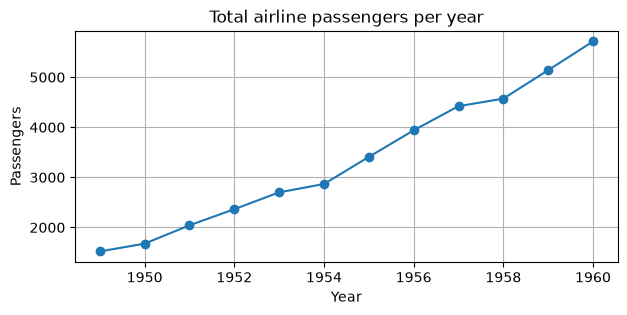

In [22]:
import matplotlib.pyplot as plt

flights = sns.load_dataset("flights")
wide = flights.pivot_table(index="year", columns="month", values="passengers", observed=True)
print(wide.iloc[:3, :4])                     # first 3 years, first 4 months

yearly = flights.groupby("year")["passengers"].sum()
yearly.plot(kind="line", marker="o", figsize=(7, 3),
            title="Total airline passengers per year")
plt.xlabel("Year"); plt.ylabel("Passengers")
plt.grid(True)
plt.show()

[Back to the Table of Contents](#toc)